# PINN Introduction

#### The static, linear Euler-Bernoulli beam

---

Lecture: "Physics-Aware Machine Learning" @ Cyber-Physical Simulation, TU Darmstadt

Lecturer: Prof. Oliver Weeger

Content creators: Jasper O. Schommartz

Summer term 2025

---

#### In this notebook, you will...

* Define boundary conditions for a Linear Euler Bernoulli Beam (LEBB)
* Define beam properties and generate data using numerical methods for training
* Define and train a Physics-Informed Neural Network to approximate the beam behaviour
* Evaluate and compare performance of the PINN-model with numerically generated data
* Further, perform two tasks to see the effect of the following approaches on the model performance:
  * Dedimensionalization
  * Boundary Conditions

In [ ]:
# Run this cell is you are using Google Colab
!git clone https://github.com/CPSHub/LecturePhysicsAwareML.git
%cd LecturePhysicsAwareML/PINNs
%pip install -e .

In [1]:
# Run this cell, if you are working locally
%cd ..
%pip install -e .

C:\Users\awast\Desktop\PAML_SS25\pythonProject\PAML_SS25\PINNs
Obtaining file:///C:/Users/awast/Desktop/PAML_SS25/pythonProject/PAML_SS25/PINNs
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Obtaining dependency information for jax from https://files.pythonhosted.org/packages/86/bb/fdc6513a9aada13fd21e9860e2adee5f6eea2b4f0a145b219288875acb26/jax-0.5.3-py3-none-any.whl.metadata
  Obtaining dependency information for equinox from https://files.pythonhosted.org/packages/8e/27/4d9db47b7ac12aedf0c3d7774e5df2c1f211d3b6610b82dd40a8bd36657b/equinox-0.


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Introduction
## 1. Theory of the geometrically linear Euler-Bernoulli beam

For this task we consider a cantilever beam with *fixed* support on the on the left an a transversal force acting on the free end of the beam.

![Beam](beam.png)

In the nonlinear case, the mechanical behavior of a cantilever beam is described by the coupled partial differential equations (PDEs)

$$
- N' = f(x) \quad\quad\quad\quad\quad (1)
$$
$$
- (Nw')' - M'' = q(x) \quad\quad(2),
$$

where $N = EA (u' + 0.5 (w')^2)$ and $M = - EI w ''$. The PDEs describe the balance of momentum in horizontal and vertical direction, respectively. If we assume the vertical displacements $w$ to be small, the PDEs can be decoupled, enabling separate computation of $u$ and $w$. In this task we are going to consider the vertical component of the decoupled system, which we refer to as the *linear Euler-Bernoulli beam*.

**Linear Euler-Bernoulli beam**

The mechanical behavior of the linear beam is decribed by a fourth order differential equation, which reads

$$
EI w^{(4)} = q(x).
$$

Here, $w$ is the vertical displacement and $q(x)$ denotes a transversal line load depending on the horizontal location $x$. The Young's modulus and the moment of inertia are denoted by $E$ and $I$, respectively. The Dirichlet boundary conditions of the cantilever beam are given by

$$
w(0) = w'(0) = 0
$$

and the Neumann boundary conditions read

$$
Q(L) = F,\quad M(L) = 0.
$$

### Non-dimensionalization:

As the Young's modulus $E$ and the moment of intertia $I$ can take large/small values in practice, it can be benefitial to non-dimensionalize the equations before training a physics-informed neural network (PINN). Therefore, we introduce the non-dimensional variables $\hat{x}$ and $\hat{w}$ as

$$ x = x_c \cdot \hat{x}\quad\text{and}\quad w = w_c \cdot \hat{w}, $$

and the non-dimensional derivatives $\hat{w}'$, $\hat{w}''$, $\hat{w}'''$, $\hat{w}^{(4)}$ as

$$ w' = \frac{w_c}{x_c} \hat{w}',\quad w'' = \frac{w_c}{x_c^2} \hat{w}'',\quad w''' = \frac{w_c}{x_c^3} \hat{w}''',\quad w^{(4)} = \frac{w_c}{x_c^4} \hat{w}^{(4)},$$

We choose $x_c = L$, which after insertion into the differential equation yields

$$
w_c = \frac{L^4}{E I}
$$

The *non-dimensional boundary value problem* (BVP) ultimatly reads

$$
\hat{w}^{(4)} =  \frac{x_c^4}{EI w_c} q(x_c \cdot \hat{x})
$$

with 

$$
\hat{w}(0) = 0,\quad \hat{w}'(0) = 0
$$

and

$$
E I \frac{w_c}{x_c^3} \hat{w}'''(1) = F,\quad \hat{w}''(1) = 0
$$

### Define boundary conditions.

In [1]:
import jax.numpy as jnp
from paml_pinns.lebb import Config, get_data_decorator


@get_data_decorator
def get_data(config: Config):
    if config.bc_case == 0:
        w_bc_coords = jnp.array([0.0])
        w_bc_values = jnp.array([0.0])
        w_x_bc_coords = jnp.array([0.0])
        w_x_bc_values = jnp.array([0.0])
        M_bc_coords = jnp.array([config.L])
        M_bc_values = jnp.array([0.0])
        Q_bc_coords = jnp.array([config.L])
        Q_bc_values = jnp.array([config.F])
    elif config.bc_case == 1:
        # Start of task scope
        ######################
        pass  # remove this for testing
        # w_bc_coords =
        # w_bc_values =
        # w_x_bc_coords =
        # w_x_bc_values =
        # M_bc_coords =
        # M_bc_values =
        # Q_bc_coords =
        # Q_bc_values =
        ######################
        # End of task scope
    else:
        NotImplementedError(
            "Data generation is not implemented for these boundary conditions."
        )

    bc = {
        "w_bc_coords": w_bc_coords,
        "w_bc_values": w_bc_values,
        "w_x_bc_coords": w_x_bc_coords,
        "w_x_bc_values": w_x_bc_values,
        "M_bc_coords": M_bc_coords,
        "M_bc_values": M_bc_values,
        "Q_bc_coords": Q_bc_coords,
        "Q_bc_values": Q_bc_values,
    }
    return bc


### Configure beam properties.

In [3]:
from paml_pinns.lebb import get_config_decorator
from typing import Tuple


@get_config_decorator
def get_config(bc_case: int) -> Tuple[float, float, float, float]:
    if bc_case == 0:
        EI = 1e6
        L = 1.0
        F = 1.0
        q = 0.0
    elif bc_case == 1:
        EI = 1e6
        L = 1.0
        F = 0.0  # Unused dummy
        q = 1.0
    else:
        NotImplementedError(
            "No configuration implemented for these boundary conditions."
        )

    return EI, L, F, q

### Data generation, model creation & training
![PINN beam](PINN_beam.png)


In [4]:
import jax
from paml_pinns.lebb import PINN


config = get_config(bc_case=0, non_dim=True)
x, y, bc, EI, L, q = get_data(config)
weights = {"w_bc": 1.0, "w_x_bc": 1.0, "M_bc": 1.0, "Q_bc": 1.0, "rw": 1.0}

key = jax.random.PRNGKey(1234)
model = PINN(EI, L, q, bc, key=key)


### Model evaluation



Step: 0,	Loss: 1.0935132503509521
Step: 1000,	Loss: 0.00035797787131741643
Step: 2000,	Loss: 7.445113442372531e-05
Step: 3000,	Loss: 4.651850395021029e-05
Step: 4000,	Loss: 3.866374754579738e-05
Step: 5000,	Loss: 4.1703453462105244e-05
Step: 6000,	Loss: 3.4101103665307164e-05
Step: 7000,	Loss: 2.067573404929135e-05
Step: 8000,	Loss: 1.1270056347711943e-05
Step: 9000,	Loss: 8.256450200860854e-06
Step: 10000,	Loss: 4.684924988396233e-06
Step: 11000,	Loss: 2.8060849217581563e-06
Step: 12000,	Loss: 4.2223323362122755e-06
Step: 13000,	Loss: 1.318109411840851e-06
Step: 14000,	Loss: 7.888606887718197e-07
Step: 15000,	Loss: 1.3213541478762636e-06
Step: 16000,	Loss: 3.0753781175008044e-06
Step: 17000,	Loss: 2.726626689764089e-06
Step: 18000,	Loss: 2.1444284357130527e-06
Step: 19000,	Loss: 3.83625820177258e-06
Step: 20000,	Loss: 5.077166633782326e-07
Step: 21000,	Loss: 3.548318318280508e-06
Step: 22000,	Loss: 1.6756794138927944e-06
Step: 23000,	Loss: 3.4841707474697614e-07
Step: 24000,	Loss: 3.1

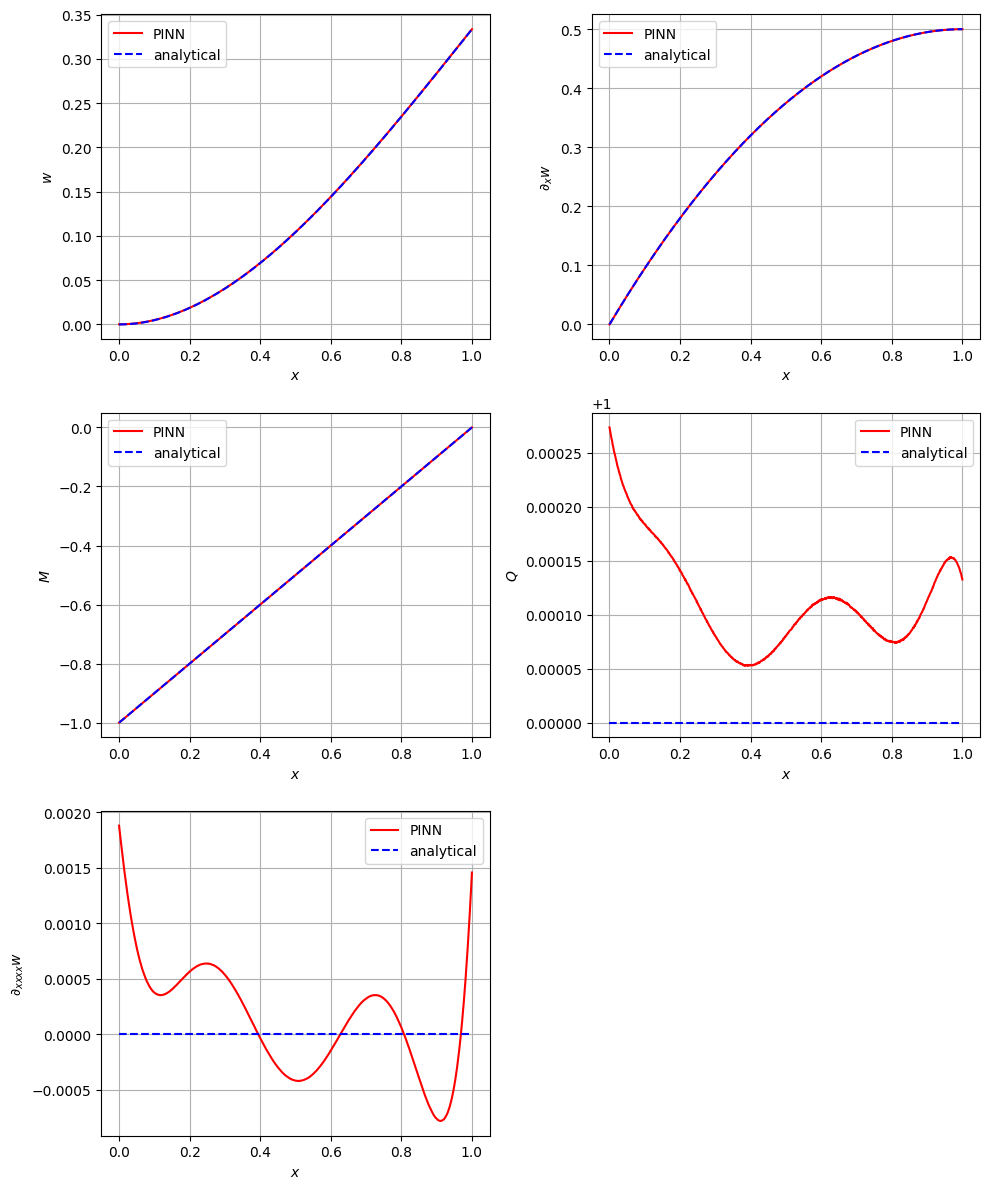

In [5]:
from paml_pinns import train
from paml_pinns.lebb import evaluate


model = train(model, x, weights, steps=50_000)
evaluate(model, x, y)

### Tasks

#### Task 1: Dedimensionalization

For `bc_case=0`, ...

a) Set `EI=1e6`, and `non_dim=False`. Can the model approximate the solution?

b) Now set the `EI = 1.0`. Can the model approximate the solution now?

c) Set `EI=1e6` again and set `non_dim=True`. The model should now be able approximate the solution very well. Why does it work better than a)?  

#### Task 2: Boundary conditions

Fix the boundary conditions for `bc_case=1` withing `get_data()`. Next, calibrate the PINN and test your implementation against the analytical solution. Note, boundary conditions can be set equal to `None`to be ignored.

*Solution proposal:*

In [9]:
import jax.numpy as jnp

from paml_pinns.lebb import Config, get_data_decorator


@get_data_decorator
def get_data(config: Config):
    if config.bc_case == 1:
        w_bc_coords = jnp.array([0.0, config.L])
        w_bc_values = jnp.array([0.0, 0.0])
        w_x_bc_coords = None
        w_x_bc_values = None
        M_bc_coords = jnp.array([0.0, config.L])
        M_bc_values = jnp.array([0.0, 0.0])
        Q_bc_coords = None
        Q_bc_values = None
    else:
        NotImplementedError(
            "Data generation is not implemented for these boundary conditions."
        )

    bc = {
        "w_bc_coords": w_bc_coords,
        "w_bc_values": w_bc_values,
        "w_x_bc_coords": w_x_bc_coords,
        "w_x_bc_values": w_x_bc_values,
        "M_bc_coords": M_bc_coords,
        "M_bc_values": M_bc_values,
        "Q_bc_coords": Q_bc_coords,
        "Q_bc_values": Q_bc_values,
    }
    return bc